In [5]:
import os 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import random 
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from collections import Counter 
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

In [6]:
def load_data(path):
    files = []
    labels = []

    for label in os.listdir(path):
        label_path = os.path.join(path, label)
        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                files.append(os.path.join(label_path, file))
                labels.append(label)    
    
    return files, labels 

In [7]:
path = os.path.join('plantvillage_dataset/color')
files, labels = load_data(path)

train_files, temp_files, train_labels, temp_labels = train_test_split(
    files,
    labels,
    test_size=0.2,
    random_state=42, 
    stratify=labels
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, 
    temp_labels,
    test_size=0.5,
    random_state=42, 
    stratify=temp_labels
)

In [8]:
print("Total treino:", len(train_files))
print("Total validação:", len(val_files))
print("Total teste:", len(test_files))

print("Classes treino:", len(set(train_labels)))
print("Classes validação:", len(set(val_labels)))
print("Classes teste:", len(set(test_labels)))

print("\nDistribuição treino:")
print(Counter(train_labels))
print("\nDistribuição validação:")
print(Counter(val_labels))
print("\nDistribuição teste:")
print(Counter(test_labels))

Total treino: 43444
Total validação: 5430
Total teste: 5431
Classes treino: 38
Classes validação: 38
Classes teste: 38

Distribuição treino:
Counter({'Orange___Haunglongbing_(Citrus_greening)': 4405, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 4286, 'Soybean___healthy': 4072, 'Peach___Bacterial_spot': 1837, 'Tomato___Bacterial_spot': 1702, 'Tomato___Late_blight': 1527, 'Squash___Powdery_mildew': 1468, 'Tomato___Septoria_leaf_spot': 1417, 'Tomato___Spider_mites Two-spotted_spider_mite': 1341, 'Apple___healthy': 1316, 'Tomato___healthy': 1273, 'Blueberry___healthy': 1202, 'Pepper,_bell___healthy': 1182, 'Tomato___Target_Spot': 1123, 'Grape___Esca_(Black_Measles)': 1106, 'Corn_(maize)___Common_rust_': 953, 'Grape___Black_rot': 944, 'Corn_(maize)___healthy': 930, 'Strawberry___Leaf_scorch': 887, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 861, 'Cherry_(including_sour)___Powdery_mildew': 842, 'Tomato___Early_blight': 800, 'Potato___Early_blight': 800, 'Potato___Late_blight': 800, 'Pepper,_b

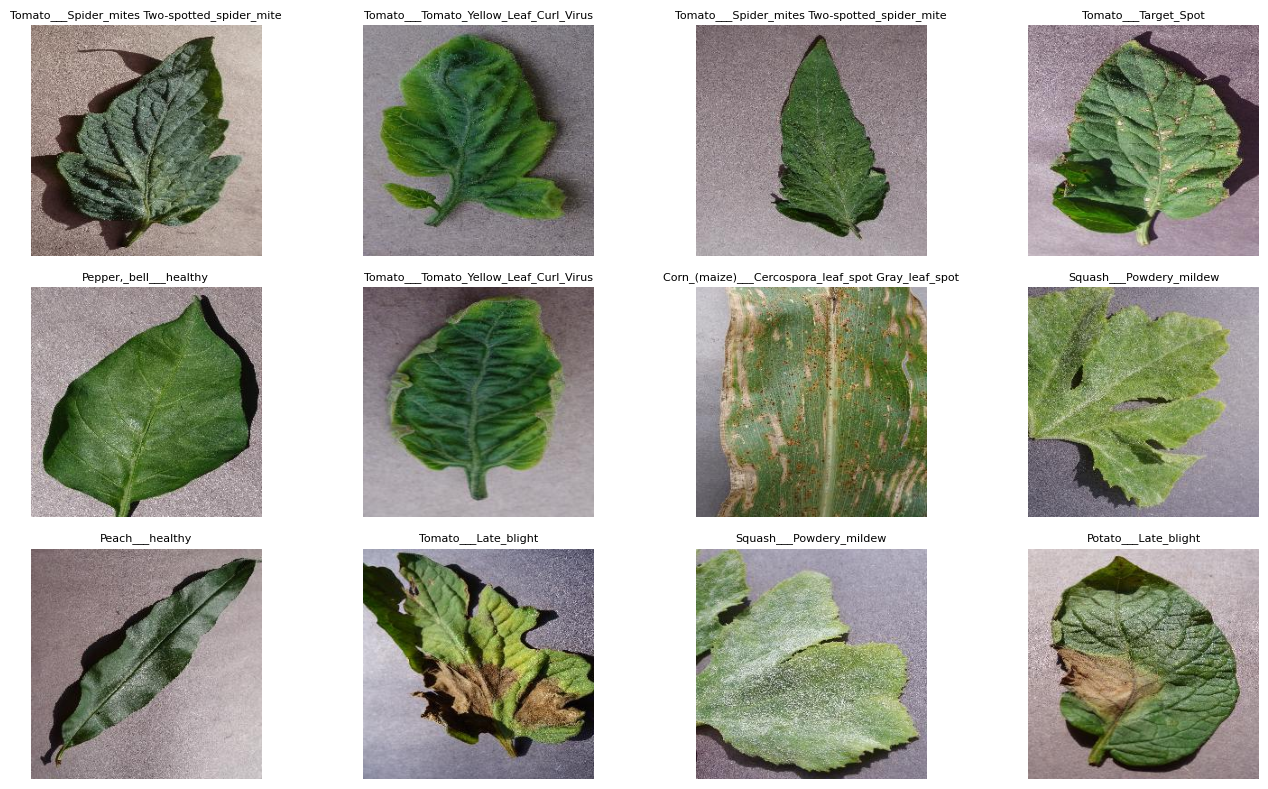

In [9]:
indices = random.sample(range(len(train_files)), 12)

plt.figure(figsize=(14, 8))

for i, idx in enumerate(indices):
    img = Image.open(train_files[idx]).convert("RGB")
    label = train_labels[idx]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
class_names = sorted(set(labels))

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
num_classes = len(class_names)

print("Número de classes:", len(class_names))
print(class_to_idx)

Número de classes: 38
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Lat

In [11]:
train_label_ids = [class_to_idx[label] for label in train_labels]
val_label_ids = [class_to_idx[label] for label in val_labels]
test_label_ids = [class_to_idx[label] for label in test_labels]

In [12]:
img_size = (224, 224)
batch_size = 16

def load_image(image_path, label_id): 
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)
   
    return image, label_id

In [13]:
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_label_ids))
val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_label_ids))
test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_label_ids))

In [24]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .shuffle(buffer_size=4096, seed=42)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

TypeError: in user code:

    File "C:\Users\samue\AppData\Local\Temp\ipykernel_3720\572938870.py", line 5, in load_image  *
        image = tf.io.read_file(image_path)

    TypeError: Input 'filename' of 'ReadFile' Op has type float32 that does not match expected type of string.


In [15]:
for images, targets in train_ds.take(1):
    print(images.shape)
    print(targets.shape)
    print(targets[:10])

(16, 224, 224, 3)
(16,)
tf.Tensor([26  1 14  1 24 12 16 30 15 16], shape=(10,), dtype=int32)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..216.16835].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..212.02545].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..206.60692].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..240.53574].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [45.071423..254.67346].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [10.326305..225.79619].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.13268].
Clipping input data to

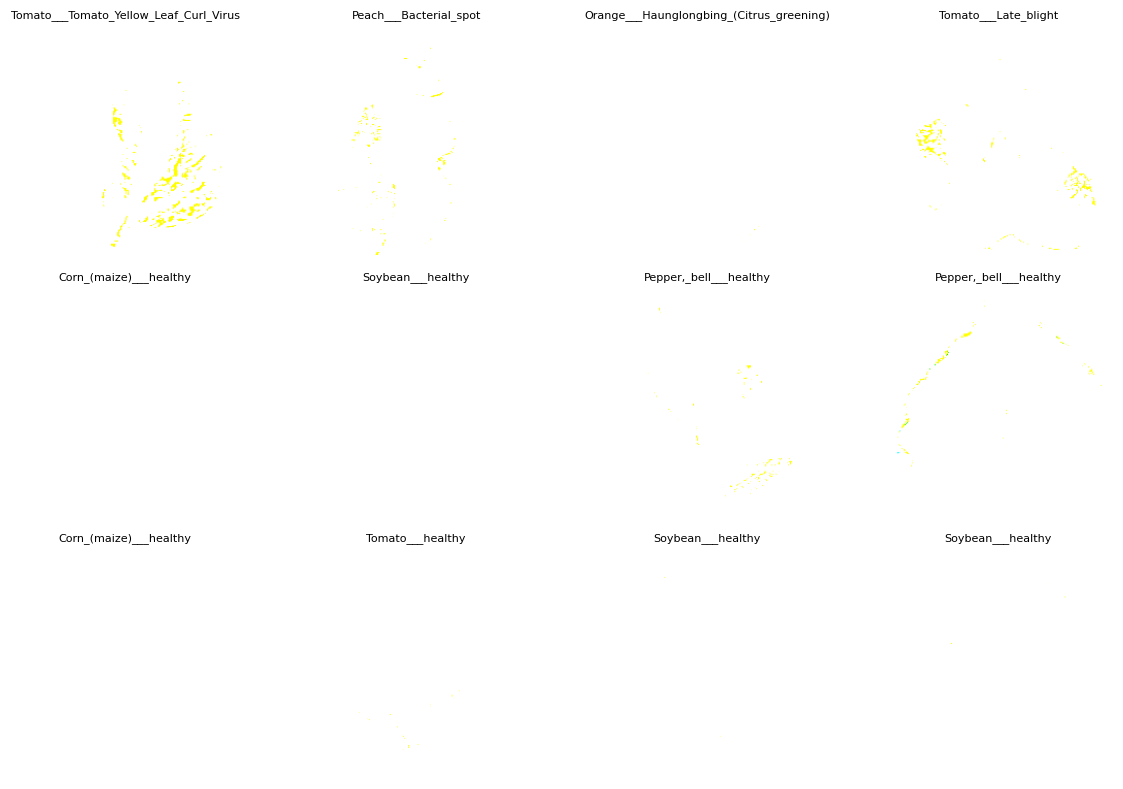

In [16]:
for images, targets in train_ds.take(1):
    plt.figure(figsize=(12, 8))

    for i in range(12):
        label_id = int(targets[i])
        label_name = idx_to_class[label_id]

        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        plt.title(label_name, fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [17]:
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
# EPOCHS = 5

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS
# )

In [21]:
# val_loss, val_acc = model.evaluate(val_ds)

# print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

In [22]:
y_true = []
y_pred = []

for images, labels_batch in val_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(pred_classes)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.0000    0.0000    0.0000        63
                                 Apple___Black_rot     0.0278    0.1774    0.0480        62
                          Apple___Cedar_apple_rust     0.0000    0.0000    0.0000        28
                                   Apple___healthy     0.0000    0.0000    0.0000       164
                               Blueberry___healthy     0.0000    0.0000    0.0000       150
          Cherry_(including_sour)___Powdery_mildew     0.0000    0.0000    0.0000       105
                 Cherry_(including_sour)___healthy     0.0000    0.0000    0.0000        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.0000    0.0000    0.0000        52
                       Corn_(maize)___Common_rust_     0.0000    0.0000    0.0000       119
               Corn_(maize)___Northern_Leaf_Blight     0.0000    0.0000    0.00

c:\Users\samue\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\samue\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\samue\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

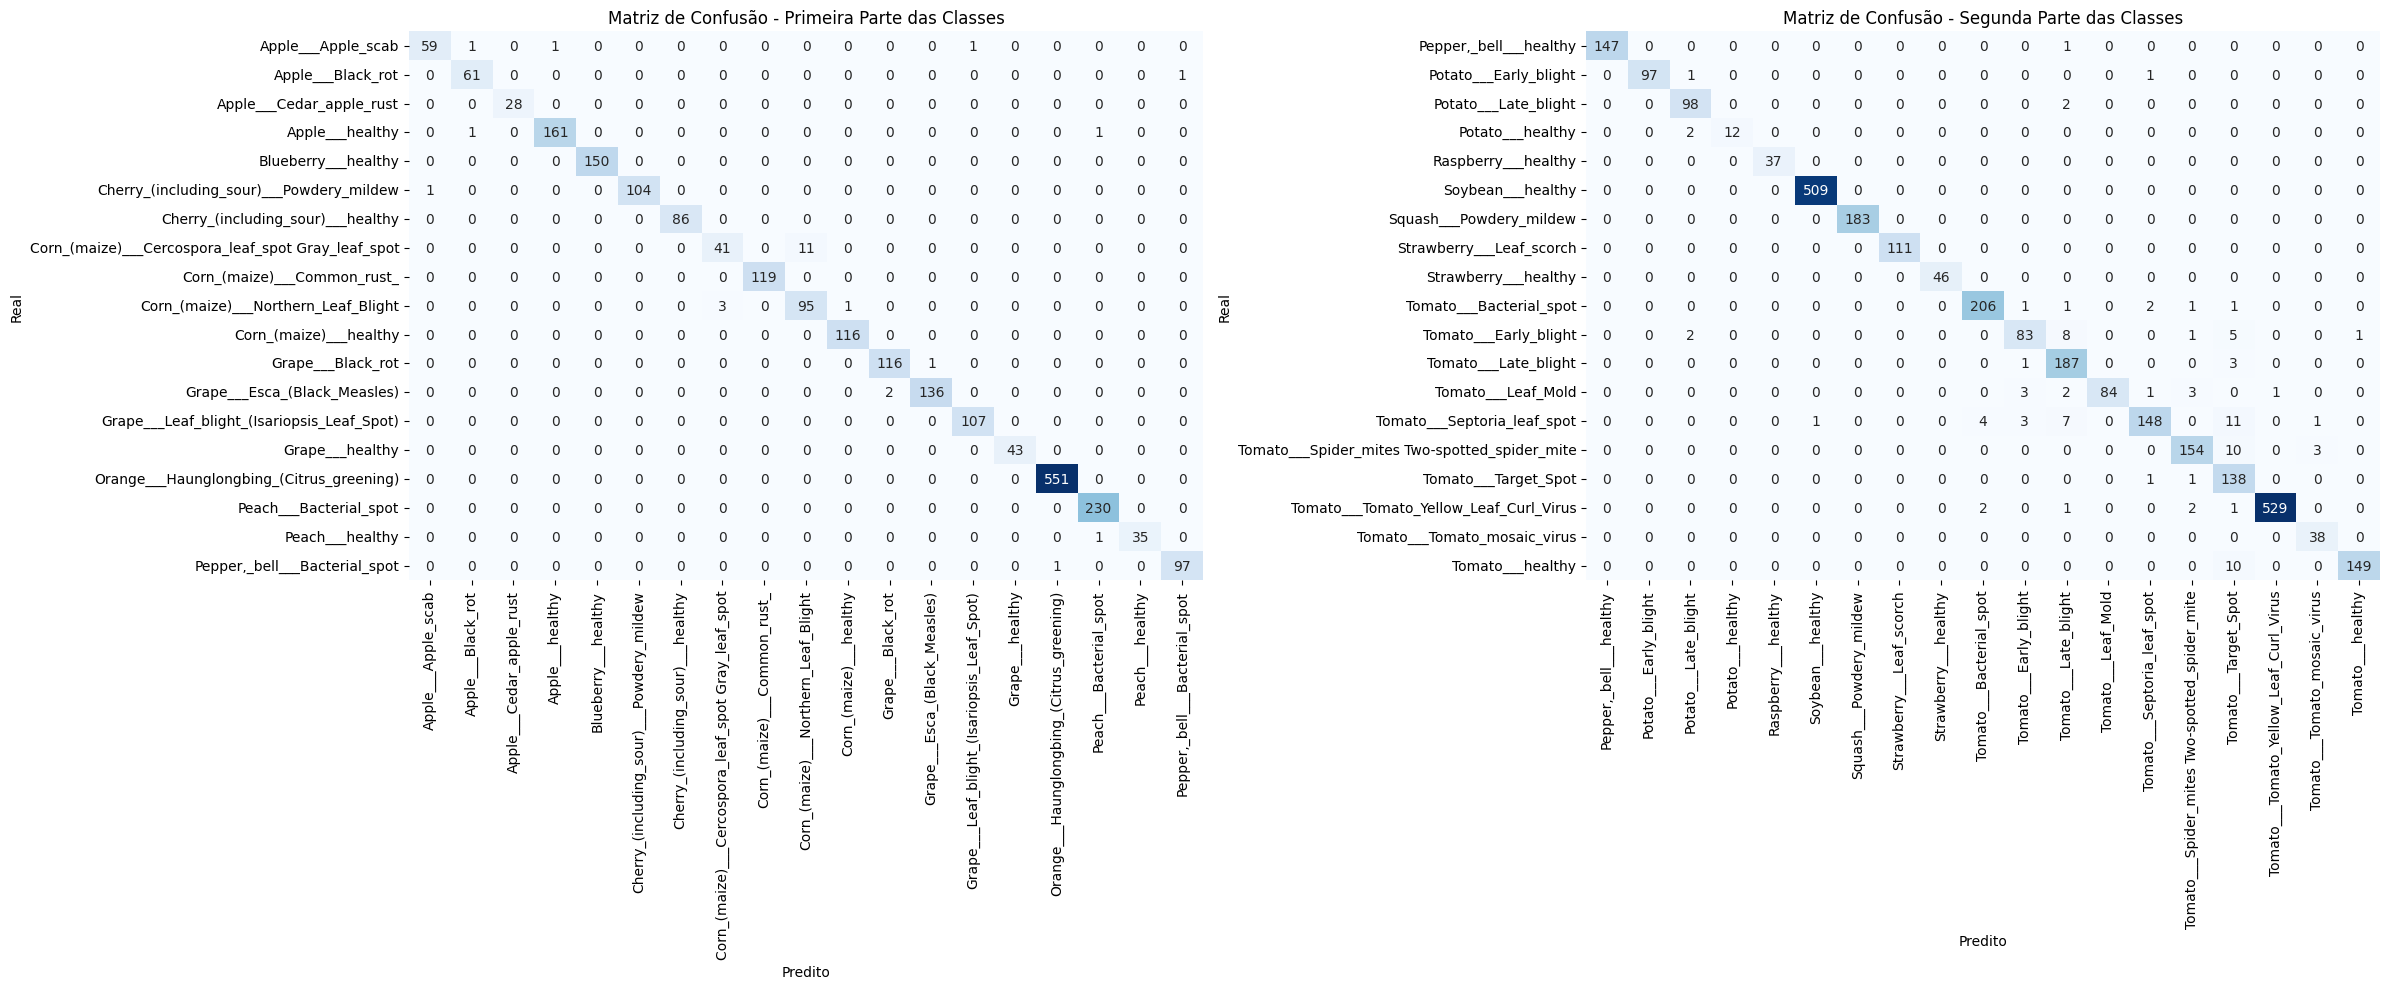

In [ ]:
cm = confusion_matrix(y_true, y_pred)

n_classes = len(class_names)
mid = n_classes // 2

# Criamos dois subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Lista para iterar sobre os cortes
splits = [
    (0, mid, "Primeira Parte das Classes"),
    (mid, n_classes, "Segunda Parte das Classes")
]

for i, (start, end, title) in enumerate(splits):
    # Fatiamos a matriz original: pegamos todas as linhas, mas apenas as colunas do intervalo
    # Se quiser uma visão estrita do quadrante, fatie também as linhas: cm[start:end, start:end]
    subset_cm = cm[start:end, start:end]
    subset_names = class_names[start:end]
    
    sns.heatmap(
        subset_cm,
        ax=axes[i],
        xticklabels=subset_names,
        yticklabels=subset_names,
        cmap="Blues",
        fmt="d",
        annot=True, # Adicionar valores dentro é útil se os quadrados forem grandes o suficiente
        cbar=False
    )
    axes[i].set_title(f"Matriz de Confusão - {title}")
    axes[i].set_xlabel("Predito")
    axes[i].set_ylabel("Real")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
errors = []

for images, labels_batch in val_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    for i in range(len(labels_batch)):
        true_id = int(labels_batch[i])
        pred_id = int(pred_classes[i])

        if true_id != pred_id:
            confidence = float(np.max(preds[i]))
            errors.append((images[i].numpy(), true_id, pred_id, confidence))

print("Total de erros:", len(errors))

Total de erros: 139


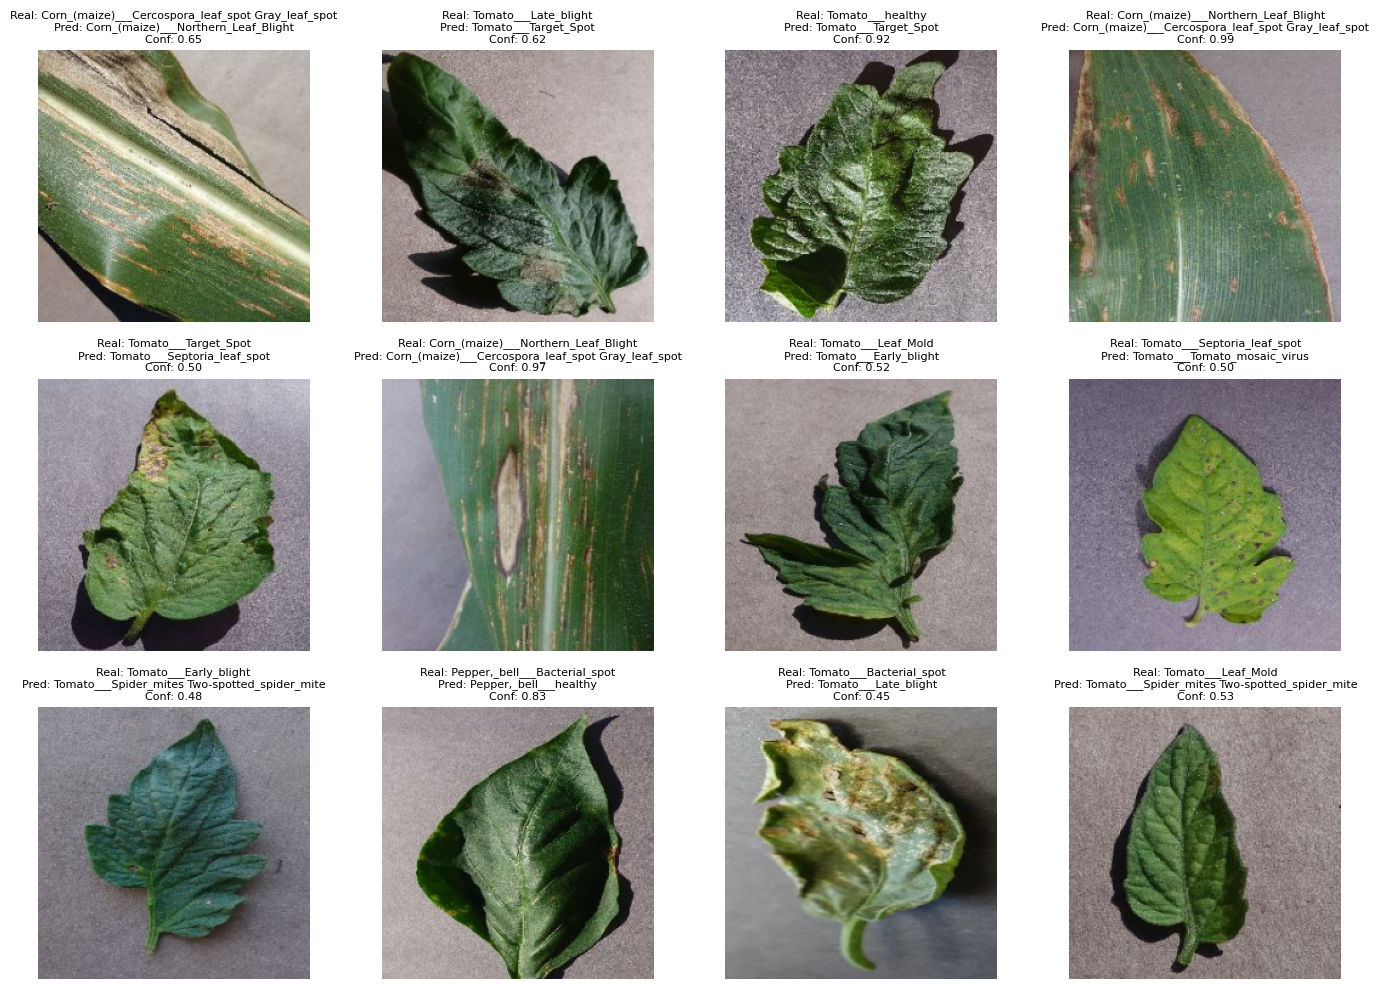

In [ ]:

plt.figure(figsize=(14, 10))

for i, (img, true_id, pred_id, conf) in enumerate(errors[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(
        f"Real: {idx_to_class[true_id]}\nPred: {idx_to_class[pred_id]}\nConf: {conf:.2f}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# test_loss, test_accuracy = model.evaluate(test_ds)

# print(f"Test Loss: {test_loss:.4f}")
# print(f"Test Accuracy: {test_accuracy:.4f}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 141s 414ms/step - accuracy: 0.9740 - loss: 0.0872
Test Loss: 0.0872
Test Accuracy: 0.9740


In [ ]:
model.save("models/efficientnet_b0_baseline.keras")

In [ ]:
model = tf.keras.models.load_model("models/efficientnet_b0_baseline.keras")  
base_model = model.layers[1]     
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
for layer in base_model.layers: 
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

In [ ]:
# fine_tune_history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=10,
#     callbacks=callbacks
# )

Epoch 1/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9738 - loss: 0.0799

In [ ]:
model = tf.keras.models.load_model("models/efficientnet_b0_fine_tuned_5_epochs.keras")
y_true = []
y_pred = []

for images, labels_batch in val_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(pred_classes)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

NameError: name 'tf' is not defined